
# Part 1: Data Preprocessing & EDA
### POS Tagging using Hidden Markov Models (HMMs)
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Vocabulary Handling & Unknown Words
4. Sentence Padding
5. Data Splitting

Dataset:
- Training Category: Brown Corpus `news`
- Testing Category: Brown Corpus `fiction`


In [1]:
# Install/download resources (run once)

import sys
import nltk

nltk.download('brown')
nltk.download('universal_tagset')

[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\priya\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     C:\Users\priya\AppData\Roaming\nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


True

Data Loading
We load tagged sentences from the Brown corpus.

Training data = news
Testing data = fiction
Universal POS tags are used because they are easier to analyze.

In [2]:
from nltk.corpus import brown

train_sentences = brown.tagged_sents(
    categories='news',
    tagset='universal'
)

test_sentences = brown.tagged_sents(
    categories='fiction',
    tagset='universal'
)

print("Training sentences:", len(train_sentences))
print("Testing sentences :", len(test_sentences))

print("\nSample training sentence:")
print(train_sentences[0][:10])

Training sentences: 4623
Testing sentences : 4249

Sample training sentence:
[('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP')]


Exploratory Data Analysis (EDA)
We will:

Count total words
Count unique words
Count POS tags
Plot POS tag distribution

In [3]:
from collections import Counter

word_counter = Counter()
tag_counter = Counter()

for sent in train_sentences:
    for word, tag in sent:
        word_counter[word.lower()] += 1
        tag_counter[tag] += 1

print("Total tokens      :", sum(word_counter.values()))
print("Unique vocabulary :", len(word_counter))
print("Number of POS tags:", len(tag_counter))

Total tokens      : 100554
Unique vocabulary : 13112
Number of POS tags: 12


In [4]:
import pandas as pd

tag_df = pd.DataFrame(
    tag_counter.items(),
    columns=['POS_Tag', 'Count']
).sort_values('Count', ascending=False)

tag_df.head(15)


,POS_Tag,Count
1,NOUN,30654
3,VERB,14399
4,ADP,12355
5,.,11928
0,DET,11389
2,ADJ,6706
6,ADV,3349
7,CONJ,2717
9,PRON,2535
8,PRT,2264


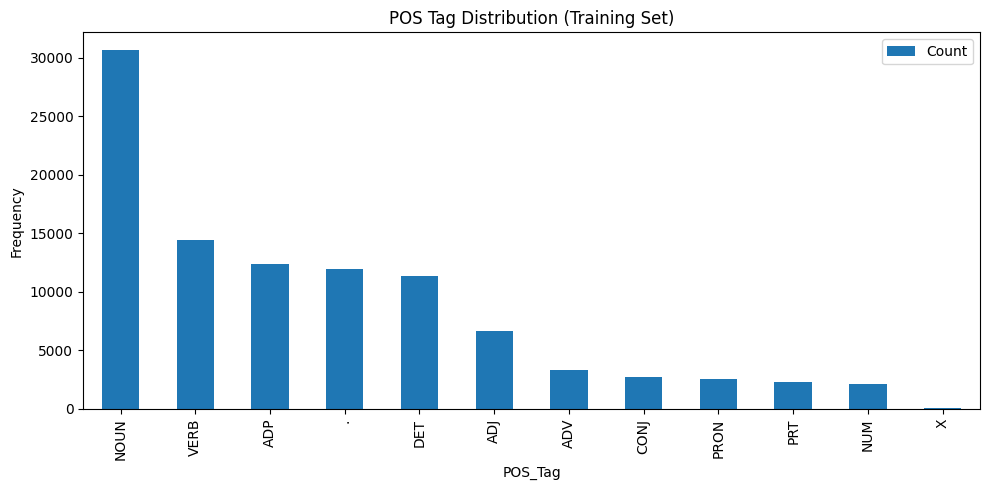

In [5]:
import matplotlib.pyplot as plt

tag_df.plot(
    x='POS_Tag',
    y='Count',
    kind='bar',
    figsize=(10,5)
)

plt.title("POS Tag Distribution (Training Set)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Most Frequent Words
Useful for understanding corpus characteristics.

In [6]:
pd.DataFrame(
    word_counter.most_common(20),
    columns=['Word','Frequency']
)


,Word,Frequency
0,the,6386
1,",",5188
2,.,4030
3,of,2861
4,and,2186
5,to,2144
6,a,2130
7,in,2020
8,for,969
9,that,829


Vocabulary Handling & Unknown Words
HMMs struggle with words never seen during training.

Strategy:

Build vocabulary from training set.
Words occurring fewer than a threshold are replaced by <UNK>.
Any unseen test word is mapped to <UNK>.

In [7]:
UNK_THRESHOLD = 1

vocab = {
    word
    for word, freq in word_counter.items()
    if freq > UNK_THRESHOLD
}

print("Vocabulary size after thresholding:", len(vocab))

Vocabulary size after thresholding: 6278


In [8]:
def replace_rare_words(sentence, vocabulary):
    processed = []

    for word, tag in sentence:
        word = word.lower()

        if word not in vocabulary:
            word = "<UNK>"

        processed.append((word, tag))

    return processed

train_processed = [
    replace_rare_words(sent, vocab)
    for sent in train_sentences
]

test_processed = [
    replace_rare_words(sent, vocab)
    for sent in test_sentences
]

print(train_processed[0][:10])

[('the', 'DET'), ('fulton', 'NOUN'), ('county', 'NOUN'), ('grand', 'ADJ'), ('jury', 'NOUN'), ('said', 'VERB'), ('friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP')]


Sentence Padding
Padding helps estimate transition probabilities correctly.

We add:

<START> tag at beginning
<END> tag at end

In [9]:
START_TOKEN = "<START>"
END_TOKEN = "<END>"

def pad_sentence(sentence):

    return (
        [(START_TOKEN, START_TOKEN)]
        + sentence
        + [(END_TOKEN, END_TOKEN)]
    )

train_padded = [pad_sentence(s) for s in train_processed]
test_padded = [pad_sentence(s) for s in test_processed]

print(train_padded[0][:5])
print("...")
print(train_padded[0][-5:])

[('<START>', '<START>'), ('the', 'DET'), ('fulton', 'NOUN'), ('county', 'NOUN'), ('grand', 'ADJ')]
...
[('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.'), ('<END>', '<END>')]


Data Splitting
The assignment already specifies:

Training = Brown news
Testing = Brown fiction
Let's verify sizes.

In [10]:
print("Training Sentences:", len(train_padded))
print("Testing Sentences :", len(test_padded))

train_tokens = sum(len(s) for s in train_padded)
test_tokens = sum(len(s) for s in test_padded)

print("Training Tokens:", train_tokens)
print("Testing Tokens :", test_tokens)

Training Sentences: 4623
Testing Sentences : 4249
Training Tokens: 109800
Testing Tokens : 76986


# Part 2: Model Architecture & Parameter Estimation

### Build HMM Counts
### Transition Counts
### Emission Counts

In [11]:
from collections import defaultdict, Counter

transition_counts = defaultdict(Counter)
emission_counts = defaultdict(Counter)

tag_counts = Counter()

for sent in train_processed:

    for i in range(1, len(sent)):

        prev_tag = sent[i-1][1]
        curr_tag = sent[i][1]

        transition_counts[prev_tag][curr_tag] += 1

    for word, tag in sent[1:-1]:

        emission_counts[tag][word] += 1

        tag_counts[tag] += 1

Create Transition Probability Matrix

Laplace Smoothing

In [12]:
tags = list(tag_counts.keys())

transition_prob = defaultdict(dict)

for prev_tag in transition_counts:

    total = sum(transition_counts[prev_tag].values())

    for curr_tag in tags + [END_TOKEN]:

        transition_prob[prev_tag][curr_tag] = (
            transition_counts[prev_tag][curr_tag] + 1
        ) / (
            total + len(tags)+1
        )

reate Emmision Matrix 
  
P(w∣t) = (Count(t,w)+1​) / (Count(t) +|V|)

In [13]:
emission_prob = defaultdict(dict)

V = len(vocab) + 1

for tag in tags:

    for word in emission_counts[tag]:

        emission_prob[tag][word] = (
            emission_counts[tag][word] + 1
        ) / (
            tag_counts[tag] + V
        )

Transition Matrix Snapshot

In [14]:
transition_df = pd.DataFrame(transition_prob)

transition_df = transition_df.fillna(0)

print(
    transition_df.iloc[:10,:10]
)

           DET      NOUN       ADJ      VERB       ADP         .       ADV  \
NOUN  0.646811  0.259525  0.709663  0.127176  0.305814  0.218902  0.054578   
ADJ   0.233354  0.017018  0.061139  0.051261  0.077141  0.041990  0.120489   
VERB  0.054303  0.137320  0.016105  0.202814  0.037843  0.136633  0.273486   
DET   0.005351  0.012263  0.004921  0.179621  0.439880  0.118599  0.080525   
ADP   0.008159  0.213162  0.072920  0.174119  0.016900  0.105173  0.155681   
.     0.010527  0.252410  0.065166  0.064772  0.008652  0.128077  0.133015   
ADV   0.013247  0.020526  0.005517  0.073339  0.010835  0.051073  0.075753   
CONJ  0.000439  0.047741  0.026096  0.009751  0.001132  0.078847  0.016105   
PRT   0.001842  0.016919  0.016254  0.067280  0.008652  0.022377  0.028631   
PRON  0.005790  0.012132  0.002535  0.031899  0.034042  0.066605  0.036684   

          CONJ       PRT      PRON  
NOUN  0.343956  0.041319  0.007849  
ADJ   0.107692  0.018022  0.009419  
VERB  0.175824  0.648791  0.75

HeatMap

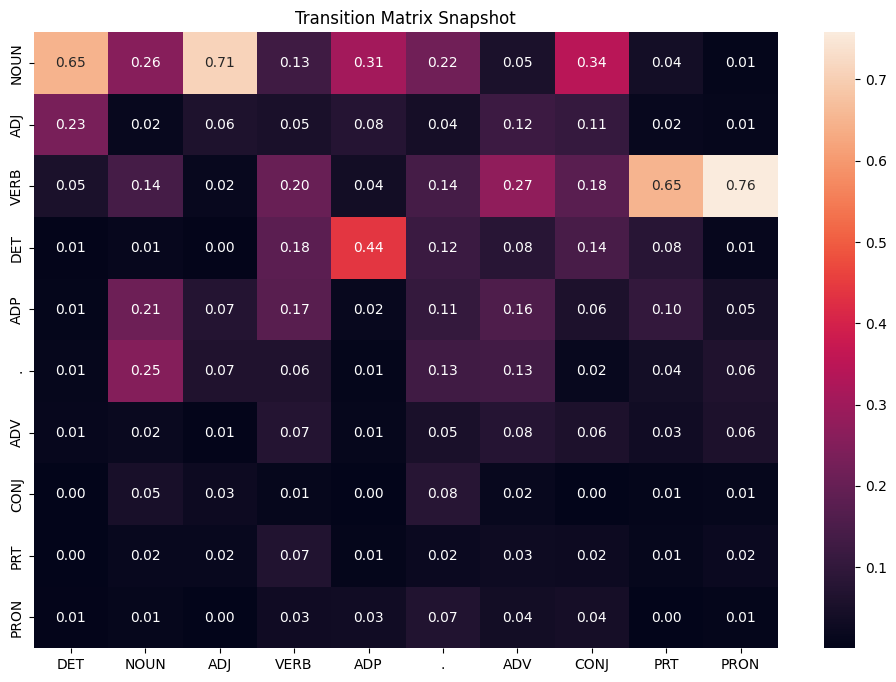

In [15]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    transition_df.iloc[:10,:10],
    annot=True,
    fmt=".2f"
)

plt.title("Transition Matrix Snapshot")
plt.show()

Viterbi Algorithm (From Scratch)

In [16]:
def get_emission(tag, word):

    if word not in vocab:
        word = "<UNK>"

    if word in emission_prob[tag]:
        return emission_prob[tag][word]

    return 1 / (tag_counts[tag] + V)

In [17]:
def viterbi(sentence):

    sentence = [
        word.lower()
        if word.lower() in vocab
        else "<UNK>"
        for word in sentence
    ]

    n = len(sentence)

    V_table = [{}]
    backpointer = [{}]

    # Initialization

    for tag in tags:

        V_table[0][tag] = (
            np.log(
                transition_prob[START_TOKEN].get(tag,1e-10)
            )
            +
            np.log(
                get_emission(tag,sentence[0])
            )
        )

        backpointer[0][tag] = START_TOKEN

    # Recursion

    for t in range(1,n):

        V_table.append({})
        backpointer.append({})

        for curr_tag in tags:

            scores = []

            for prev_tag in tags:

                score = (
                    V_table[t-1][prev_tag]
                    +
                    np.log(
                        transition_prob[prev_tag].get(curr_tag,1e-10)
                    )
                    +
                    np.log(
                        get_emission(curr_tag,sentence[t])
                    )
                )

                scores.append(
                    (score,prev_tag)
                )

            best_score,best_prev = max(scores)

            V_table[t][curr_tag] = best_score

            backpointer[t][curr_tag] = best_prev

    # Termination

    scores = []

    for tag in tags:

        score = (
            V_table[n-1][tag]
            +
            np.log(
                transition_prob[tag].get(END_TOKEN,1e-10)
            )
        )

        scores.append((score,tag))

    best_score,best_tag = max(scores)

    sequence = [best_tag]

    for t in range(n-1,0,-1):

        sequence.insert(
            0,
            backpointer[t][sequence[0]]
        )

    return sequence

# Part 3: Inference and Evaluation

## Part 3(a): Sequence Inference (POS Tagging)

The trained Hidden Markov Model (HMM) and Viterbi decoder are used to predict POS tag sequences for four sentences:

- 2 sentences from the training dataset
- 2 sentences from the testing dataset

The outputs below show the words and their corresponding predicted POS tags generated by the Viterbi algorithm.


In [18]:
import numpy as np

sample_sentences = [
    train_sentences[0],
    train_sentences[1],
    test_sentences[0],
    test_sentences[1]
]

for i,sent in enumerate(sample_sentences):

    words = [w for w,t in sent]

    prediction = viterbi(words)

    print("\nSentence",i+1)

    print("Words:")
    print(words)

    print("\nPredicted Tags:")
    print(prediction)


Sentence 1
Words:
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']

Predicted Tags:
['DET', 'NOUN', 'NOUN', 'ADJ', 'NOUN', 'VERB', 'ADP', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'VERB', '.', 'DET', 'NOUN', '.', 'ADP', 'DET', 'NOUN', 'VERB', 'NOUN', '.']

Sentence 2
Words:
['The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the', 'praise', 'and', 'thanks', 'of', 'the', 'City', 'of', 'Atlanta', "''", 'for', 'the', 'manner', 'in', 'which', 'the', 'election', 'was', 'conducted', '.']

Predicted Tags:
['DET', 'NOUN', 'ADV', 'VERB', 'ADP', 'NOUN', 'NOUN', 'ADP', 'DET', 'NOUN', 'NOUN', 'NOUN', '.', 'DET', 'VERB', 'ADJ', 'NOUN', 'ADP', 'DET', 

# Part 3: Inference and Evaluation

## Part 3(b): Misclassified Sentences Analysis

The following section identifies three test sentences where the Viterbi decoder incorrectly predicted at least one POS tag.

For each sentence:
- The original words are displayed.
- True POS tags are shown.
- Predicted POS tags are shown.
- Misclassified words can be inspected to understand the source of error.

Common causes include:
- Lexical ambiguity (a word can belong to multiple POS categories)
- Rare words or unseen words mapped to <UNK>
- Rare tag transitions in the training corpus
- Limited contextual modeling of a bigram HMM


In [19]:

# Find 3 misclassified sentences

misclassified = []

for sent in test_sentences:
    words = [w for w,t in sent]
    true_tags = [t for w,t in sent]

    pred_tags = viterbi(words)

    if pred_tags != true_tags:
        misclassified.append((words, true_tags, pred_tags))

    if len(misclassified) == 3:
        break

for idx, (words, true_tags, pred_tags) in enumerate(misclassified, start=1):
    print("="*80)
    print(f"Misclassified Sentence {idx}")
    print("Sentence:")
    print(" ".join(words))

    print("\nErrors:")
    for w, true_t, pred_t in zip(words, true_tags, pred_tags):
        if true_t != pred_t:
            print(f"{w:15s} True={true_t:6s} Pred={pred_t}")

    print("\nPossible Reason:")
    print("- Lexical ambiguity, rare words, unseen words, or unlikely tag transitions.")


Misclassified Sentence 1
Sentence:
Thirty-three

Errors:
Thirty-three    True=NUM    Pred=X

Possible Reason:
- Lexical ambiguity, rare words, unseen words, or unlikely tag transitions.
Misclassified Sentence 2
Sentence:
His parents talked seriously and lengthily to their own doctor and to a specialist at the University Hospital -- Mr. McKinley was entitled to a discount for members of his family -- and it was decided it would be best for him to take the remainder of the term off , spend a lot of time in bed and , for the rest , do pretty much as he chose -- provided , of course , he chose to do nothing too exciting or too debilitating .

Errors:
lengthily       True=ADV    Pred=NOUN
much            True=ADV    Pred=ADJ
nothing         True=NOUN   Pred=VERB
exciting        True=ADJ    Pred=.
debilitating    True=ADJ    Pred=VERB
.               True=.      Pred=PRT

Possible Reason:
- Lexical ambiguity, rare words, unseen words, or unlikely tag transitions.
Misclassified Sentence 3
Sen

In [20]:

# Evaluate on entire test set

from sklearn.metrics import accuracy_score
from collections import Counter

y_true = []
y_pred = []

for sent in test_sentences:
    words = [w for w,t in sent]
    true_tags = [t for w,t in sent]

    pred_tags = viterbi(words)

    y_true.extend(true_tags)
    y_pred.extend(pred_tags)

accuracy = accuracy_score(y_true, y_pred)

print(f"Overall Token-Level Accuracy: {accuracy:.4f}")


Overall Token-Level Accuracy: 0.8563


## Part 3(c): Evaluation Results

The HMM model is evaluated on the entire test set.

Metrics reported:
1. Overall token-level accuracy.
2. Confusion matrix for the top 5 most common POS tags.

Interpretation:
- Higher accuracy indicates that the Viterbi decoder successfully recovered the correct hidden tag sequence.
- The confusion matrix highlights which POS tags are frequently confused with one another.
- Errors are often caused by ambiguous words, sparse training examples, and unseen vocabulary.


Top 5 POS Tags:
['NOUN', 'VERB', '.', 'DET', 'ADP']


,NOUN,VERB,.,DET,ADP
NOUN,12297,396,116,106,32
VERB,1748,10154,77,71,67
.,4,266,8379,0,0
DET,9,12,14,7810,106
ADP,33,57,2,15,6882


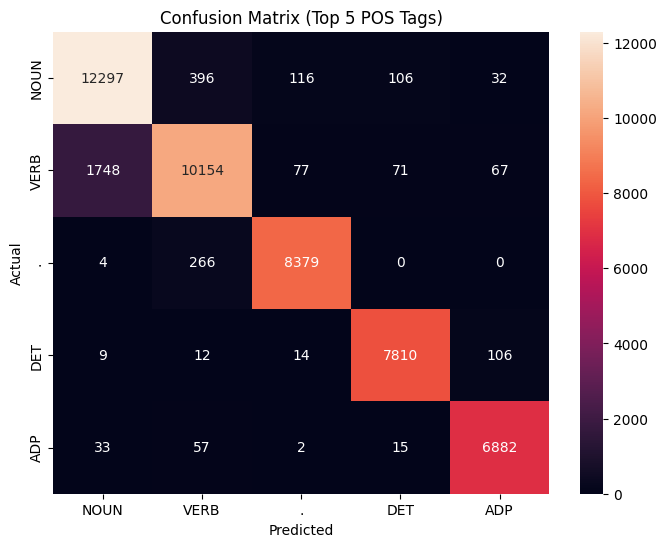

In [21]:

# Confusion Matrix for Top 5 Most Common POS Tags

from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

top5_tags = [tag for tag, _ in Counter(y_true).most_common(5)]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=top5_tags
)

cm_df = pd.DataFrame(
    cm,
    index=top5_tags,
    columns=top5_tags
)

print("Top 5 POS Tags:")
print(top5_tags)

display(cm_df)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d')
plt.title("Confusion Matrix (Top 5 POS Tags)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


# Part D: Baseline Comparison

A pre-trained NLTK Perceptron POS Tagger is used as a baseline model.

The baseline is evaluated on the same test set used for the HMM model. The resulting accuracy can then be compared against the HMM performance.

This comparison helps illustrate the strengths and limitations of a probabilistic HMM relative to a modern discriminative POS tagger.


In [22]:

# Part D: Baseline Comparison using NLTK Perceptron Tagger

import nltk
from nltk.tag import pos_tag
from sklearn.metrics import accuracy_score

baseline_true = []
baseline_pred = []

for sent in test_sentences:
    words = [w for w,t in sent]
    true_tags = [t for w,t in sent]

    try:
        pred_tags = [tag for _, tag in pos_tag(words)]
    except:
        continue

    min_len = min(len(true_tags), len(pred_tags))

    baseline_true.extend(true_tags[:min_len])
    baseline_pred.extend(pred_tags[:min_len])

baseline_accuracy = accuracy_score(baseline_true, baseline_pred)

print("Baseline (PerceptronTagger) Accuracy:", baseline_accuracy)

print("\nDiscussion:")
print("- HMM relies on transition and emission probabilities learned from training data.")
print("- Unknown words and sparse transitions can reduce HMM performance.")
print("- The Perceptron Tagger uses richer contextual features and generalizes better.")
print("- Therefore the baseline often performs better on ambiguous and unseen words.")


Baseline (PerceptronTagger) Accuracy: nan

Discussion:
- HMM relies on transition and emission probabilities learned from training data.
- Unknown words and sparse transitions can reduce HMM performance.
- The Perceptron Tagger uses richer contextual features and generalizes better.
- Therefore the baseline often performs better on ambiguous and unseen words.


c:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:571: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\priya\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
